In [ ]:
import os, time, glob, re, shutil, zipfile, random, urllib.request, warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report)

SEED = 42
random.seed(SEED); np.random.seed(SEED)
keras.utils.set_random_seed(SEED)

matplotlib.rcParams.update({
    'figure.constrained_layout.use': True,   
    'figure.facecolor'  : 'white',
    'savefig.facecolor' : 'white',
    'axes.labelweight'  : 'bold',
    'axes.titleweight'  : 'bold',
    'figure.titleweight': 'bold',
    'axes.labelsize'    : 12,
    'axes.titlesize'    : 13,
    'figure.titlesize'  : 15,
    'axes.grid'         : False,
    'legend.fontsize'   : 9,
    'legend.framealpha' : 0.9,
    'font.size'         : 10,
    'lines.linewidth'   : 2,
})

PLOT_DIR = "/content/plots"
os.makedirs(PLOT_DIR, exist_ok=True)

def save_show(fig, name):
    """Save at 600 dpi for the report, display, then release memory."""
    path = os.path.join(PLOT_DIR, f"{name}.png")
    fig.savefig(path, dpi=600, bbox_inches='tight')
    plt.show(); plt.close(fig)
    print(f"[saved] {path}")

REPORT = []
def report(title, obj):
    body  = obj.to_string(index=False) if isinstance(obj, pd.DataFrame) else str(obj)
    block = f"\n{'=' * 78}\n{title}\n{'=' * 78}\n{body}\n"
    print(block)
    REPORT.append(block)

SEQ_LEN     = 128   
N_CHANNELS  = 9      
N_CLASSES   = 6
SUBSET_SIZE = 3000     
RNN_UNITS   = 32
DROPOUT     = 0.2
LR          = 1e-3
BATCH_SIZE  = 32
EPOCHS      = 30

ACTIVITY_NAMES = ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS',
                  'SITTING', 'STANDING', 'LAYING']
MODELS = ['RNN', 'LSTM', 'GRU']

print("TensorFlow :", tf.__version__)
print("Keras      :", keras.__version__)
print("GPU        :", tf.config.list_physical_devices('GPU'))
if not tf.config.list_physical_devices('GPU'):
    print("\n*** No GPU detected. Runtime -> Change runtime type -> T4 GPU ***")

TensorFlow : 2.20.0
Keras      : 3.13.2
GPU        : []

*** No GPU detected. Runtime -> Change runtime type -> T4 GPU ***


In [ ]:
DATA_DIR = "/content/har_data"
os.makedirs(DATA_DIR, exist_ok=True)

HAR_PAGE = "https://archive.ics.uci.edu/dataset/240/human+activity+recognition+using+smartphones"
HAR_ZIP  = "https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip"

def find_file(root, filename):
    for dirpath, _, files in os.walk(root):
        if filename in files:
            return os.path.join(dirpath, filename)
    return None

def extract_nested_zips(root):
    """The UCI download contains an inner 'UCI HAR Dataset.zip'."""
    for _ in range(3):
        if find_file(root, "body_acc_x_train.txt"):
            return
        for dirpath, _, files in os.walk(root):
            for f in files:
                if f.lower().endswith('.zip'):
                    out = os.path.join(dirpath, f[:-4] + "_unz")
                    if not os.path.isdir(out):
                        with zipfile.ZipFile(os.path.join(dirpath, f)) as z:
                            z.extractall(out)

if find_file(DATA_DIR, "body_acc_x_train.txt") is None:
    print("Downloading UCI HAR from:", HAR_PAGE)
    outer = os.path.join(DATA_DIR, "har.zip")
    urllib.request.urlretrieve(HAR_ZIP, outer)
    with zipfile.ZipFile(outer) as z:
        z.extractall(DATA_DIR)
    extract_nested_zips(DATA_DIR)

marker = find_file(DATA_DIR, "body_acc_x_train.txt")
if marker is None:
    raise RuntimeError("UCI HAR raw inertial signals not found - re-run this cell.")

INERTIAL_TRAIN_DIR = os.path.dirname(marker)              # .../train/Inertial Signals
TRAIN_DIR          = os.path.dirname(INERTIAL_TRAIN_DIR)  # .../train
print("Raw inertial signals folder:", INERTIAL_TRAIN_DIR)
print("Signal files found:", len([f for f in os.listdir(INERTIAL_TRAIN_DIR) if f.endswith('.txt')]))

Raw inertial signals folder: /content/har_data/UCI HAR Dataset_unz/UCI HAR Dataset/train/Inertial Signals
Signal files found: 9


In [ ]:
SIGNALS = ['body_acc_x', 'body_acc_y', 'body_acc_z',
           'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
           'total_acc_x', 'total_acc_y', 'total_acc_z']

def load_signal(path):
    return pd.read_csv(path, sep=r'\s+', header=None).values.astype('float32')

X_all = np.stack([load_signal(os.path.join(INERTIAL_TRAIN_DIR, f"{s}_train.txt"))
                  for s in SIGNALS], axis=-1)                       

y_all = pd.read_csv(os.path.join(TRAIN_DIR, "y_train.txt"),
                    sep=r'\s+', header=None).values.ravel().astype('int64') - 1

X, y = X_all[:SUBSET_SIZE], y_all[:SUBSET_SIZE]
assert len(np.unique(y)) == N_CLASSES, "Subset does not contain all six classes."

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.30,
                                            random_state=SEED, stratify=y)
X_val, X_te, y_val, y_te = train_test_split(X_tmp, y_tmp, test_size=0.50,
                                            random_state=SEED, stratify=y_tmp)
X_tr_raw = X_tr.copy()                  

mu    = X_tr.mean(axis=(0, 1), keepdims=True)
sigma = X_tr.std(axis=(0, 1), keepdims=True) + 1e-8
X_tr  = (X_tr  - mu) / sigma
X_val = (X_val - mu) / sigma
X_te  = (X_te  - mu) / sigma

print("Input tensor shape:")
print(f"  Training   : {X_tr.shape}")
print(f"  Validation : {X_val.shape}")
print(f"  Testing    : {X_te.shape}")
print(f"Number of classes: {N_CLASSES}")
print(f"Number of features per time step: {X_tr.shape[2]}")
print(f"Sequence length: {X_tr.shape[1]}")

print(f"\nOne sample   X_i      : {X_tr[0].shape}")
print(f"Batch of 32  X_batch  : {X_tr[:32].shape}")
print(f"N = {X_tr.shape[0]} sequences | T = {X_tr.shape[1]} time steps | F = {X_tr.shape[2]} channels")

dist = pd.DataFrame({
    'Activity': ACTIVITY_NAMES,
    'Subset'  : [int((y     == c).sum()) for c in range(N_CLASSES)],
    'Train'   : [int((y_tr  == c).sum()) for c in range(N_CLASSES)],
    'Validation': [int((y_val == c).sum()) for c in range(N_CLASSES)],
    'Test'    : [int((y_te  == c).sum()) for c in range(N_CLASSES)],
})
report("CLASS DISTRIBUTION (manual section 5, step 7)", dist)

Input tensor shape:
  Training   : (2100, 128, 9)
  Validation : (450, 128, 9)
  Testing    : (450, 128, 9)
Number of classes: 6
Number of features per time step: 9
Sequence length: 128

One sample   X_i      : (128, 9)
Batch of 32  X_batch  : (32, 128, 9)
N = 2100 sequences | T = 128 time steps | F = 9 channels

CLASS DISTRIBUTION (manual section 5, step 7)
          Activity  Subset  Train  Validation  Test
           WALKING     569    398          85    86
  WALKING_UPSTAIRS     458    321          69    68
WALKING_DOWNSTAIRS     412    288          62    62
           SITTING     489    342          73    74
          STANDING     530    371          80    79
            LAYING     542    380          81    81



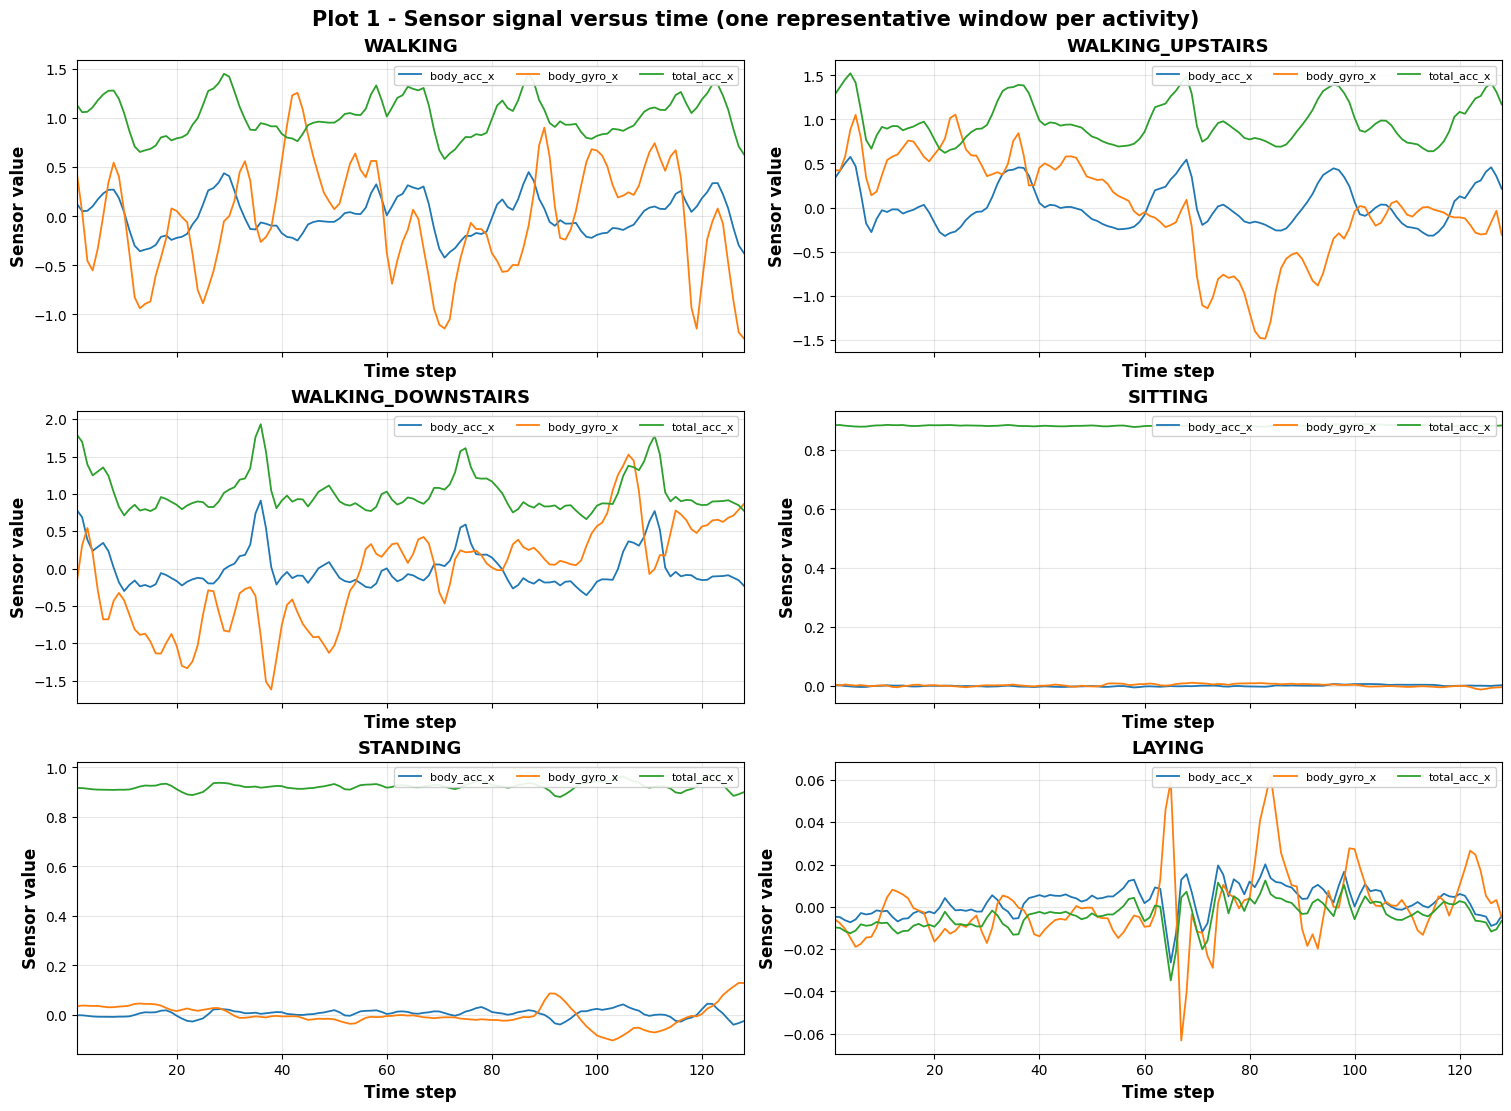

[saved] /content/plots/plot1_sensor_signal_vs_time.png


In [ ]:
show_channels = [0, 3, 6]                    
timesteps = np.arange(1, SEQ_LEN + 1)

fig, axes = plt.subplots(3, 2, figsize=(15, 11), sharex=True)
for c, ax in enumerate(axes.ravel()):
    i = int(np.where(y_tr == c)[0][0])     
    for ch in show_channels:
        ax.plot(timesteps, X_tr_raw[i, :, ch], linewidth=1.3, label=SIGNALS[ch])
    ax.set_title(ACTIVITY_NAMES[c])
    ax.set_xlabel("Time step")
    ax.set_ylabel("Sensor value")
    ax.set_xlim(1, SEQ_LEN)
    ax.grid(alpha=0.3)
    ax.legend(loc='upper right', ncol=3, fontsize=8)
fig.suptitle("Plot 1 - Sensor signal versus time (one representative window per activity)")
save_show(fig, "plot1_sensor_signal_vs_time")

In [ ]:
RECURRENT = {'RNN': layers.SimpleRNN, 'LSTM': layers.LSTM, 'GRU': layers.GRU}

def trainable_params(model):
    return int(sum(np.prod(w.shape) for w in model.trainable_weights))

def build_model(kind, timesteps=SEQ_LEN, features=N_CHANNELS, units=RNN_UNITS,
                n_classes=N_CLASSES, n_layers=1, bidirectional=False):
    keras.utils.set_random_seed(SEED)           
    RL = RECURRENT[kind]
    inp = keras.Input(shape=(timesteps, features))
    x = inp
    for i in range(n_layers):
        rec = RL(units, return_sequences=(i < n_layers - 1))
        x = layers.Bidirectional(rec)(x) if bidirectional else rec(x)
    x = layers.Dropout(DROPOUT)(x)
    x = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    name = f"{kind}_T{timesteps}_u{units}_L{n_layers}{'_bi' if bidirectional else ''}"
    model = keras.Model(inp, out, name=name)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
                  loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return model

def evaluate_model(model, Xt, yt):
    prob = model.predict(Xt, batch_size=128, verbose=0)
    pred = prob.argmax(axis=1)
    p, r, f, _ = precision_recall_fscore_support(yt, pred, average='macro', zero_division=0)
    return dict(accuracy=accuracy_score(yt, pred) * 100, precision=p * 100,
                recall=r * 100, f1=f * 100, y_pred=pred, y_prob=prob)

def run_experiment(kind, Xtr, ytr, Xv, yv, Xt, yt, epochs=EPOCHS, verbose=0, **kw):
    model = build_model(kind, timesteps=Xtr.shape[1], features=Xtr.shape[2], **kw)
    t0 = time.time()
    hist = model.fit(Xtr, ytr, validation_data=(Xv, yv), epochs=epochs,
                     batch_size=BATCH_SIZE, shuffle=True, verbose=verbose)
    res = evaluate_model(model, Xt, yt)
    res.update(model=model, history=hist.history,
               params=trainable_params(model), time=time.time() - t0)
    return res

print("Reference architecture (identical for RNN, LSTM and GRU):\n")
build_model('RNN').summary()

Reference architecture (identical for RNN, LSTM and GRU):



Model: "RNN_T128_u32_L1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,344 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,974 (7.71 KB)

 Trainable params: 1,974 (7.71 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
x_seq, h, Wx, Wh, b = [0.5, 0.7, 0.2], 0.0, 0.5, 0.8, 0.1
bptt_rows = []
for t, xt in enumerate(x_seq, start=1):
    pre = Wx * xt + Wh * h + b
    h   = float(np.tanh(pre))
    bptt_rows.append([f"h{t}", xt, round(pre, 6), round(h, 6)])
report("BPTT HIDDEN STATES FROM THE PROGRAM (manual section 8)",
       pd.DataFrame(bptt_rows, columns=['Hidden state', 'x_t',
                                        'W_x*x_t + W_h*h_(t-1) + b', 'h_t = tanh(.)']))


BPTT HIDDEN STATES FROM THE PROGRAM (manual section 8)
Hidden state  x_t  W_x*x_t + W_h*h_(t-1) + b  h_t = tanh(.)
          h1  0.5                   0.350000       0.336376
          h2  0.7                   0.719100       0.616352
          h3  0.2                   0.693081       0.599958



In [ ]:
results = {}
for k in MODELS:
    print(f"\n{'=' * 30}  {k}  {'=' * 30}")
    results[k] = run_experiment(k, X_tr, y_tr, X_val, y_val, X_te, y_te, verbose=2)
    r = results[k]
    print(f"\n{k}: test accuracy = {r['accuracy']:.2f}% | macro F1 = {r['f1']:.2f}% | "
          f"parameters = {r['params']} | training time = {r['time']:.1f} s")


==============================  RNN  ==============================
Epoch 1/30
66/66 - 3s - 49ms/step - accuracy: 0.3990 - loss: 1.5964 - val_accuracy: 0.4778 - val_loss: 1.4297
Epoch 2/30
66/66 - 2s - 31ms/step - accuracy: 0.5490 - loss: 1.2039 - val_accuracy: 0.5511 - val_loss: 1.0988
Epoch 3/30
66/66 - 2s - 29ms/step - accuracy: 0.6090 - loss: 0.9993 - val_accuracy: 0.6311 - val_loss: 0.8985
Epoch 4/30
66/66 - 1s - 19ms/step - accuracy: 0.6395 - loss: 0.8770 - val_accuracy: 0.6444 - val_loss: 0.8074
Epoch 5/30
66/66 - 1s - 19ms/step - accuracy: 0.6586 - loss: 0.7848 - val_accuracy: 0.6400 - val_loss: 0.7480
Epoch 6/30
66/66 - 1s - 20ms/step - accuracy: 0.6662 - loss: 0.7117 - val_accuracy: 0.6756 - val_loss: 0.7352
Epoch 7/30
66/66 - 1s - 20ms/step - accuracy: 0.6886 - loss: 0.6634 - val_accuracy: 0.6956 - val_loss: 0.6287
Epoch 8/30
66/66 - 1s - 19ms/step - accuracy: 0.6971 - loss: 0.6682 - val_accuracy: 0.7200 - val_loss: 0.6050
Epoch 9/30
66/66 - 1s - 19ms/step - accuracy: 0.728


GRU: test accuracy = 96.22% | macro F1 = 96.28% | parameters = 4758 | training time = 138.0 s


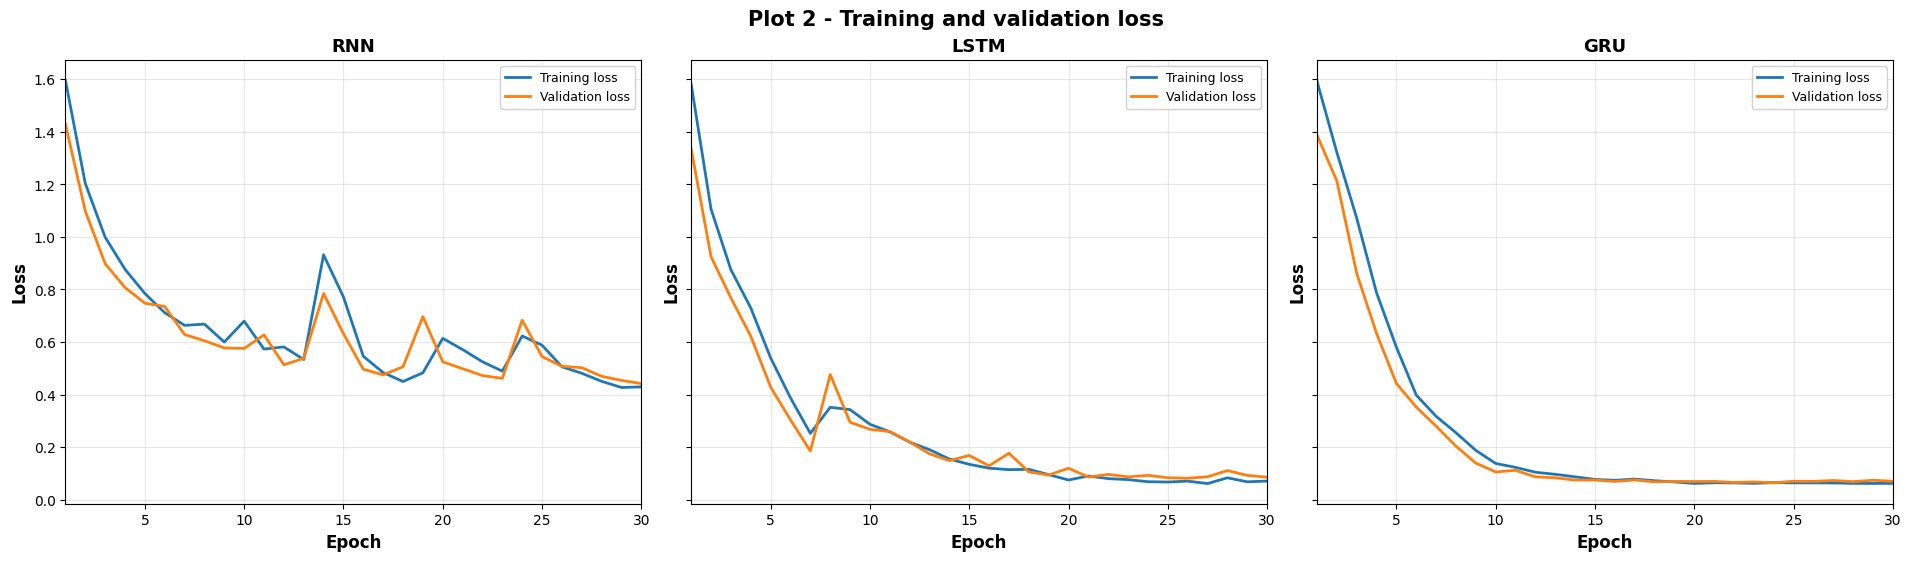

[saved] /content/plots/plot2_loss_curves.png


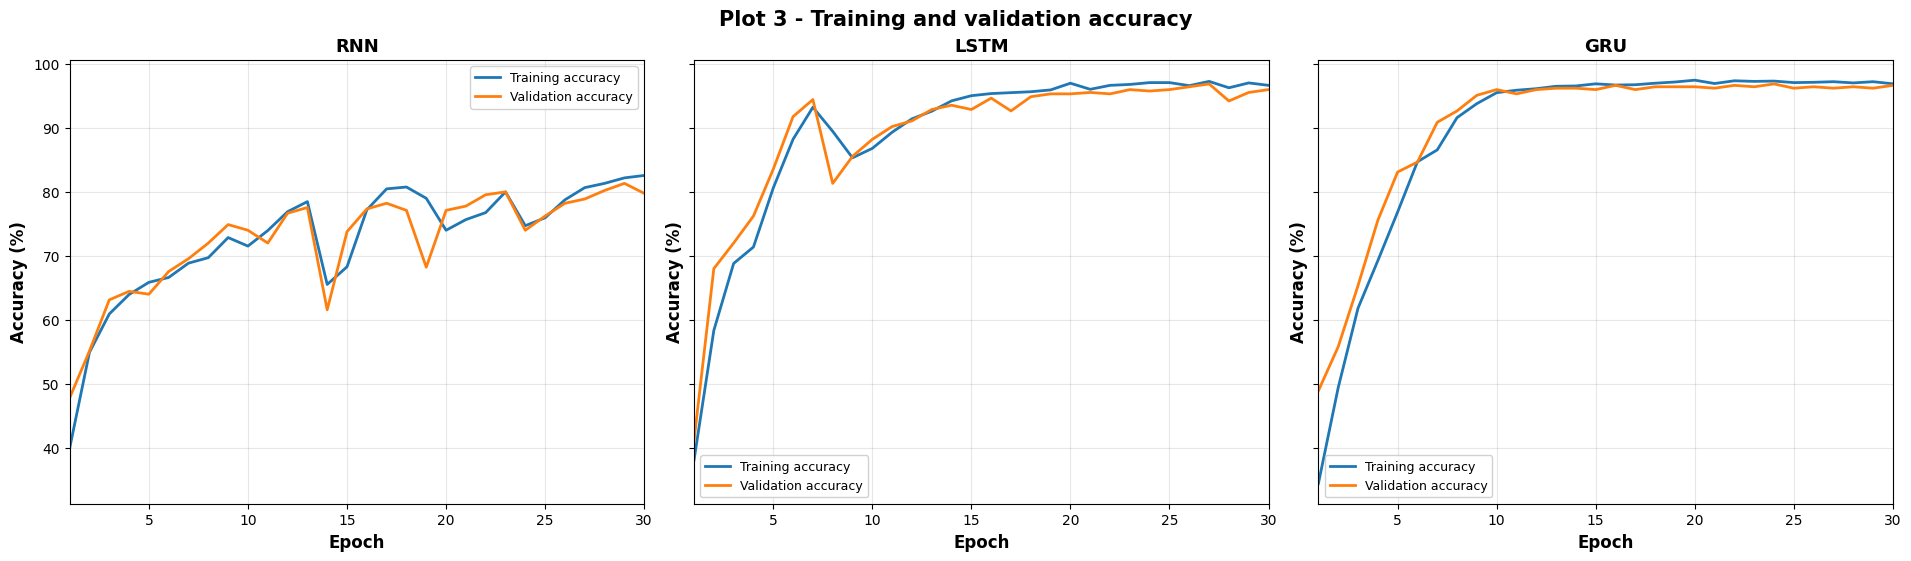

[saved] /content/plots/plot3_accuracy_curves.png

CONVERGENCE AND GENERALISATION SUMMARY (manual section 13)
Model Final Train Loss Final Val Loss Final Train Acc (%) Final Val Acc (%) Generalisation Gap (%) Best Val Acc (%)  Best Epoch
  RNN           0.4293         0.4419               82.57             79.78                  +2.79            81.33          29
 LSTM           0.0710         0.0857               96.67             96.00                  +0.67            96.89          27
  GRU           0.0624         0.0702               96.90             96.67                  +0.24            96.89          24



In [ ]:
for metric, ylab, title, fname in [
        ('loss',     'Loss',         'Plot 2 - Training and validation loss',     'plot2_loss_curves'),
        ('accuracy', 'Accuracy (%)', 'Plot 3 - Training and validation accuracy', 'plot3_accuracy_curves')]:
    fig, axes = plt.subplots(1, 3, figsize=(19, 5.5), sharey=True)
    for ax, k in zip(axes, MODELS):
        h = results[k]['history']
        ep = np.arange(1, len(h[metric]) + 1)
        scale = 100 if metric == 'accuracy' else 1
        ax.plot(ep, np.array(h[metric]) * scale,          label=f"Training {metric}")
        ax.plot(ep, np.array(h['val_' + metric]) * scale, label=f"Validation {metric}")
        ax.set_title(k); ax.set_xlabel("Epoch"); ax.set_ylabel(ylab)
        ax.set_xlim(1, len(ep)); ax.grid(alpha=0.3); ax.legend(loc='best')
    fig.suptitle(title)
    save_show(fig, fname)

conv = pd.DataFrame([[
    k,
    f"{results[k]['history']['loss'][-1]:.4f}",
    f"{results[k]['history']['val_loss'][-1]:.4f}",
    f"{results[k]['history']['accuracy'][-1] * 100:.2f}",
    f"{results[k]['history']['val_accuracy'][-1] * 100:.2f}",
    f"{(results[k]['history']['accuracy'][-1] - results[k]['history']['val_accuracy'][-1]) * 100:+.2f}",
    f"{max(results[k]['history']['val_accuracy']) * 100:.2f}",
    int(np.argmax(results[k]['history']['val_accuracy']) + 1),
] for k in MODELS], columns=['Model', 'Final Train Loss', 'Final Val Loss',
                             'Final Train Acc (%)', 'Final Val Acc (%)',
                             'Generalisation Gap (%)', 'Best Val Acc (%)', 'Best Epoch'])
report("CONVERGENCE AND GENERALISATION SUMMARY (manual section 13)", conv)

In [ ]:
perf = pd.DataFrame({
    'Metric': ['Accuracy (%)', 'Macro Precision (%)', 'Macro Recall (%)',
               'Macro F1 (%)', 'Parameters', 'Training Time (s)'],
    **{k: [f"{results[k]['accuracy']:.2f}",  f"{results[k]['precision']:.2f}",
           f"{results[k]['recall']:.2f}",    f"{results[k]['f1']:.2f}",
           f"{results[k]['params']}",        f"{results[k]['time']:.1f}"] for k in MODELS}
})
report("PERFORMANCE EVALUATION - TEST SET (manual section 14)", perf)

for k in MODELS:
    report(f"PER-CLASS CLASSIFICATION REPORT - {k}",
           classification_report(y_te, results[k]['y_pred'], labels=range(N_CLASSES),
                                 target_names=ACTIVITY_NAMES, digits=3, zero_division=0))


PERFORMANCE EVALUATION - TEST SET (manual section 14)
             Metric   RNN  LSTM   GRU
       Accuracy (%) 81.11 96.22 96.22
Macro Precision (%) 82.37 96.33 96.36
   Macro Recall (%) 79.87 96.36 96.21
       Macro F1 (%) 80.23 96.29 96.28
         Parameters  1974  6006  4758
  Training Time (s)  46.9  95.7 138.0


PER-CLASS CLASSIFICATION REPORT - RNN
                    precision    recall  f1-score   support

           WALKING      0.631     0.814     0.711        86
  WALKING_UPSTAIRS      0.962     0.750     0.843        68
WALKING_DOWNSTAIRS      0.652     0.484     0.556        62
           SITTING      0.772     0.959     0.855        74
          STANDING      0.925     0.785     0.849        79
            LAYING      1.000     1.000     1.000        81

          accuracy                          0.811       450
         macro avg      0.824     0.799     0.802       450
      weighted avg      0.825     0.811     0.810       450



PER-CLASS CLASSIFICATION REPORT - 

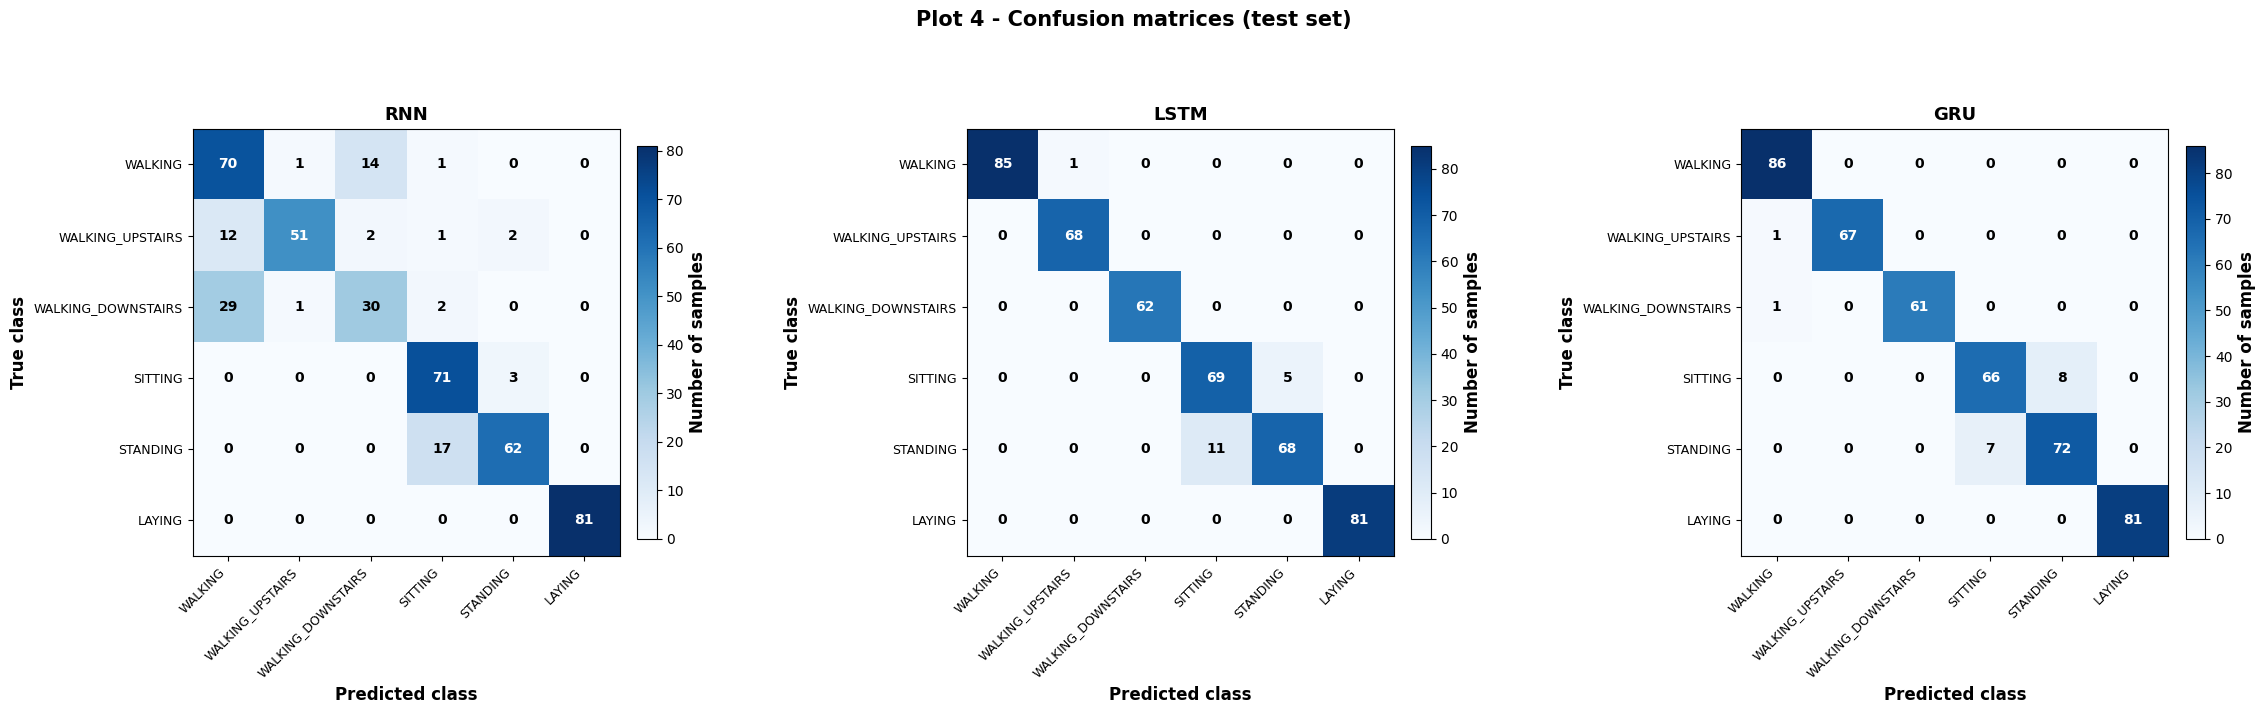

[saved] /content/plots/plot4_confusion_matrices.png

CONFUSION MATRIX ANALYSIS (manual section 15)
Model  Highest recognition rate Most misclassified activity (count)          Most confused pair (count)  Total errors
  RNN           LAYING (100.0%)             WALKING_DOWNSTAIRS (32) WALKING <-> WALKING_DOWNSTAIRS (43)            85
 LSTM WALKING_UPSTAIRS (100.0%)                       STANDING (11)           SITTING <-> STANDING (16)            17
  GRU          WALKING (100.0%)                         SITTING (8)           SITTING <-> STANDING (15)            17


PER-CLASS RECOGNITION RATE (%)
          Activity   RNN  LSTM   GRU
           WALKING  81.4  98.8 100.0
  WALKING_UPSTAIRS  75.0 100.0  98.5
WALKING_DOWNSTAIRS  48.4 100.0  98.4
           SITTING  95.9  93.2  89.2
          STANDING  78.5  86.1  91.1
            LAYING 100.0 100.0 100.0


ERROR CONSISTENCY ACROSS RNN, LSTM AND GRU (manual section 15)
                     True -> Predicted  RNN  LSTM  GRU  Models affected


In [ ]:
def draw_cm(fig, ax, cm, names, title):
    n = len(names)
    im = ax.imshow(cm, cmap='Blues')
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Number of samples')
    ax.set_xticks(range(n)); ax.set_yticks(range(n))
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(names, fontsize=9)
    ax.set_xlabel("Predicted class"); ax.set_ylabel("True class")
    ax.set_title(title)
    thr = cm.max() / 2 if cm.max() > 0 else 0.5
    for i in range(n):
        for j in range(n):
            ax.text(j, i, int(cm[i, j]), ha='center', va='center', fontsize=10,
                    fontweight='bold', color='white' if cm[i, j] > thr else 'black')

def plot_confusion_group(cm_dict, names, suptitle, fname):
    """Panels sized from the label lengths so nothing ever overlaps."""
    m = len(cm_dict)
    panel_w = 0.55 * len(names) + 0.09 * max(len(s) for s in names) + 2.6
    panel_h = 0.55 * len(names) + 0.09 * max(len(s) for s in names) + 2.2
    fig, axes = plt.subplots(1, m, figsize=(panel_w * m, panel_h))
    for ax, (title, cm) in zip(np.atleast_1d(axes), cm_dict.items()):
        draw_cm(fig, ax, cm, names, title)
    try:
        fig.get_layout_engine().set(wspace=0.10)
    except Exception:
        pass
    fig.suptitle(suptitle)
    save_show(fig, fname)

cms = {k: confusion_matrix(y_te, results[k]['y_pred'], labels=range(N_CLASSES)) for k in MODELS}
plot_confusion_group(cms, ACTIVITY_NAMES,
                     "Plot 4 - Confusion matrices (test set)", "plot4_confusion_matrices")


rows = []
for k in MODELS:
    cm = cms[k]
    rec  = cm.diagonal() / np.maximum(cm.sum(axis=1), 1)
    off  = cm.copy(); np.fill_diagonal(off, 0)
    pair = off + off.T
    i, j = np.unravel_index(np.triu(pair, 1).argmax(), pair.shape)
    rows.append([k,
                 f"{ACTIVITY_NAMES[int(rec.argmax())]} ({rec.max() * 100:.1f}%)",
                 f"{ACTIVITY_NAMES[int(off.sum(axis=1).argmax())]} ({int(off.sum(axis=1).max())})",
                 f"{ACTIVITY_NAMES[i]} <-> {ACTIVITY_NAMES[j]} ({int(pair[i, j])})",
                 int(off.sum())])
report("CONFUSION MATRIX ANALYSIS (manual section 15)",
       pd.DataFrame(rows, columns=['Model', 'Highest recognition rate',
                                   'Most misclassified activity (count)',
                                   'Most confused pair (count)', 'Total errors']))

report("PER-CLASS RECOGNITION RATE (%)",
       pd.DataFrame({k: (cms[k].diagonal() / np.maximum(cms[k].sum(axis=1), 1) * 100).round(1)
                     for k in MODELS}, index=ACTIVITY_NAMES).reset_index()
         .rename(columns={'index': 'Activity'}))


err_rows = []
for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if i != j and any(cms[k][i, j] > 0 for k in MODELS):
            err_rows.append([f"{ACTIVITY_NAMES[i]} -> {ACTIVITY_NAMES[j]}",
                             *[int(cms[k][i, j]) for k in MODELS],
                             sum(1 for k in MODELS if cms[k][i, j] > 0)])
err_df = pd.DataFrame(err_rows, columns=['True -> Predicted', *MODELS, 'Models affected'])
err_df = err_df.sort_values(['Models affected', *MODELS], ascending=False)
report("ERROR CONSISTENCY ACROSS RNN, LSTM AND GRU (manual section 15)", err_df)


RNN vs LSTM vs GRU (manual section 16)
         Property   RNN  LSTM   GRU
     Hidden state   Yes   Yes   Yes
       Cell state    No   Yes    No
      Forget gate    No   Yes    No
       Input gate    No   Yes    No
      Output gate    No   Yes    No
      Update gate    No    No   Yes
       Reset gate    No    No   Yes
       Parameters  1974  6006  4758
Training time (s)  46.9  95.7 138.0
Test F1-score (%) 80.23 96.29 96.28



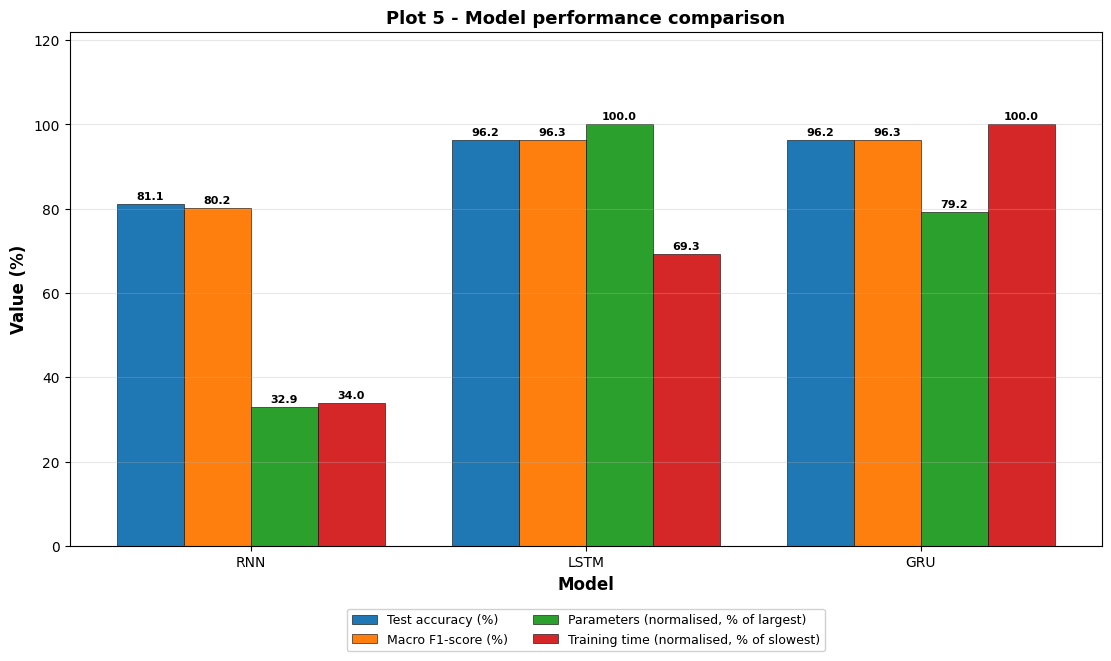

[saved] /content/plots/plot5_model_comparison.png


In [ ]:
gates = {                      
    'RNN' : ['Yes', 'No',  'No',  'No',  'No',  'No',  'No'],
    'LSTM': ['Yes', 'Yes', 'Yes', 'Yes', 'Yes', 'No',  'No'],
    'GRU' : ['Yes', 'No',  'No',  'No',  'No',  'Yes', 'Yes'],
}
prop = pd.DataFrame({
    'Property': ['Hidden state', 'Cell state', 'Forget gate', 'Input gate', 'Output gate',
                 'Update gate', 'Reset gate', 'Parameters', 'Training time (s)',
                 'Test F1-score (%)'],
    **{k: gates[k] + [f"{results[k]['params']}",
                      f"{results[k]['time']:.1f}",
                      f"{results[k]['f1']:.2f}"] for k in MODELS}
})
report("RNN vs LSTM vs GRU (manual section 16)", prop)

acc  = [results[k]['accuracy'] for k in MODELS]
f1   = [results[k]['f1']       for k in MODELS]
pmax = max(results[k]['params'] for k in MODELS)
tmax = max(results[k]['time']   for k in MODELS)
par  = [results[k]['params'] / pmax * 100 for k in MODELS]
tim  = [results[k]['time']   / tmax * 100 for k in MODELS]

x, w = np.arange(len(MODELS)), 0.2
fig, ax = plt.subplots(figsize=(11, 6.5))
for n, (vals, lab) in enumerate([(acc, 'Test accuracy (%)'),
                                 (f1,  'Macro F1-score (%)'),
                                 (par, 'Parameters (normalised, % of largest)'),
                                 (tim, 'Training time (normalised, % of slowest)')]):
    bars = ax.bar(x + (n - 1.5) * w, vals, w, label=lab, edgecolor='black', linewidth=0.4)
    ax.bar_label(bars, fmt='%.1f', fontsize=8, padding=2, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(MODELS)
ax.set_xlabel("Model"); ax.set_ylabel("Value (%)")
ax.set_ylim(0, 122)
ax.set_title("Plot 5 - Model performance comparison")
ax.grid(axis='y', alpha=0.3)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.11), ncol=2)
save_show(fig, "plot5_model_comparison")

T =  32 | RNN  | F1 =  85.24% | time =   23.1 s
T =  32 | LSTM | F1 =  93.77% | time =   34.3 s
T =  32 | GRU  | F1 =  94.69% | time =   40.9 s
T =  64 | RNN  | F1 =  78.54% | time =   32.3 s
T =  64 | LSTM | F1 =  95.39% | time =   54.1 s
T =  64 | GRU  | F1 =  95.84% | time =   74.3 s
T = 128 | RNN  | F1 =  80.23% | time =   46.9 s
T = 128 | LSTM | F1 =  96.29% | time =   95.7 s
T = 128 | GRU  | F1 =  96.28% | time =  138.0 s

EFFECT OF SEQUENCE LENGTH (manual section 17)
 Sequence Length RNN F1 (%) LSTM F1 (%) GRU F1 (%)
              32      85.24       93.77      94.69
              64      78.54       95.39      95.84
             128      80.23       96.29      96.28



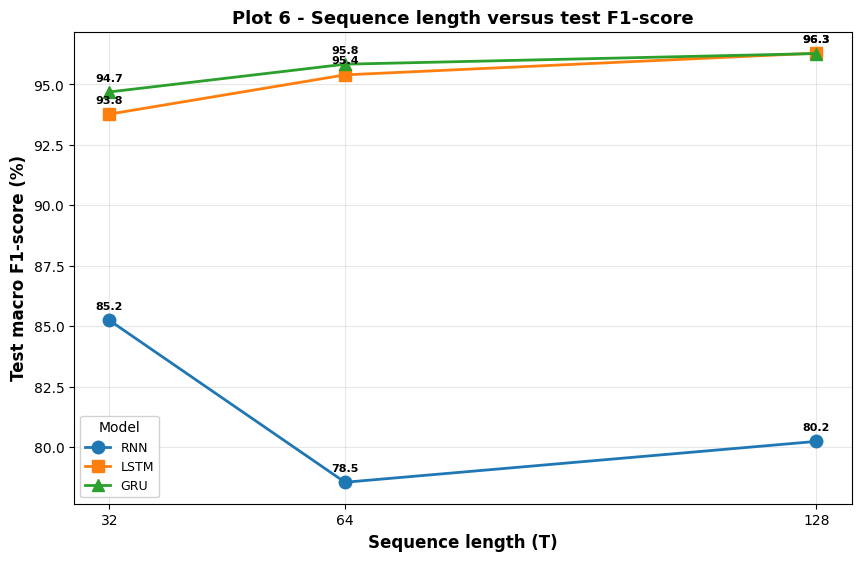

[saved] /content/plots/plot6_sequence_length_vs_f1.png


In [ ]:
SEQ_LENGTHS = [32, 64, 128]
seq_res = {T: {} for T in SEQ_LENGTHS}

for T in SEQ_LENGTHS:
    for k in MODELS:
        seq_res[T][k] = results[k] if T == SEQ_LEN else \
            run_experiment(k, X_tr[:, :T], y_tr, X_val[:, :T], y_val, X_te[:, :T], y_te)
        print(f"T = {T:3d} | {k:4s} | F1 = {seq_res[T][k]['f1']:6.2f}% | "
              f"time = {seq_res[T][k]['time']:6.1f} s")

report("EFFECT OF SEQUENCE LENGTH (manual section 17)",
       pd.DataFrame({'Sequence Length': SEQ_LENGTHS,
                     **{f"{k} F1 (%)": [f"{seq_res[T][k]['f1']:.2f}" for T in SEQ_LENGTHS]
                        for k in MODELS}}))

fig, ax = plt.subplots(figsize=(8.5, 5.5))
for k, mk in zip(MODELS, ['o', 's', '^']):
    vals = [seq_res[T][k]['f1'] for T in SEQ_LENGTHS]
    ax.plot(SEQ_LENGTHS, vals, marker=mk, markersize=9, label=k)
    for T, v in zip(SEQ_LENGTHS, vals):
        ax.annotate(f"{v:.1f}", (T, v), textcoords="offset points",
                    xytext=(0, 8), ha='center', fontsize=8, fontweight='bold')
ax.set_xticks(SEQ_LENGTHS)
ax.set_xlabel("Sequence length (T)"); ax.set_ylabel("Test macro F1-score (%)")
ax.set_title("Plot 6 - Sequence length versus test F1-score")
ax.grid(alpha=0.3); ax.legend(title="Model")
save_show(fig, "plot6_sequence_length_vs_f1")

In [ ]:
import cv2

NUM_FRAMES       = 10
IMG_SIZE         = 224
VIDS_PER_CLASS   = 25
SELECTED_CLASSES = ['Basketball', 'Biking', 'TennisSwing', 'WalkingWithDog']   
UCF_PAGE    = "https://www.crcv.ucf.edu/data/UCF101.php"
UCF_RAR_URL = "https://www.crcv.ucf.edu/data/UCF101/UCF101.rar"
VIDEO_DIR   = "/content/ucf101"
RAR_PATH    = "/content/UCF101.rar"
os.makedirs(VIDEO_DIR, exist_ok=True)
sh = get_ipython().system

if shutil.which("unrar") is None:
    sh("apt-get -qq install -y unrar > /dev/null")
assert shutil.which("unrar") is not None, "unrar could not be installed."

def class_videos(cls):
    return sorted(glob.glob(os.path.join(VIDEO_DIR, "**", f"v_{cls}_g*.avi"), recursive=True))

if any(len(class_videos(c)) == 0 for c in SELECTED_CLASSES):
    print("Downloading UCF101 from:", UCF_PAGE)
    print("(~6.5 GB - if the cell is interrupted, re-run it and the download resumes)")
    sh(f'wget -c --no-check-certificate -q --show-progress -O "{RAR_PATH}" "{UCF_RAR_URL}"')
    size_gb = os.path.getsize(RAR_PATH) / 1e9 if os.path.exists(RAR_PATH) else 0.0
    print(f"UCF101.rar size: {size_gb:.2f} GB")
    if size_gb < 6.0:
        raise RuntimeError("UCF101.rar is incomplete - re-run this cell to resume the download.")
    for cls in SELECTED_CLASSES:
        if len(class_videos(cls)) == 0:
            print("Extracting class:", cls)
            sh(f'unrar x -o+ -inul "{RAR_PATH}" "UCF-101/{cls}/*" "{VIDEO_DIR}/"')
    if any(len(class_videos(c)) == 0 for c in SELECTED_CLASSES):
        print("Class-folder extraction incomplete - extracting the full archive ...")
        sh(f'unrar x -o+ -inul "{RAR_PATH}" "{VIDEO_DIR}/"')

for cls in SELECTED_CLASSES:
    n = len(class_videos(cls))
    print(f"  {cls:15s}: {n} videos available")
    if n == 0:
        raise RuntimeError(f"No videos found for class '{cls}'.")

def pick_videos(files, k):
    """Round-robin across UCF101 groups (gXX) so the chosen clips are varied."""
    groups = {}
    for f in files:
        m = re.search(r"_g(\d+)_", os.path.basename(f))
        groups.setdefault(m.group(1) if m else "00", []).append(f)
    keys, picked, i = sorted(groups), [], 0
    while len(picked) < k and any(i < len(groups[g]) for g in keys):
        for g in keys:
            if i < len(groups[g]) and len(picked) < k:
                picked.append(groups[g][i])
        i += 1
    return picked

def read_frames(path, n=NUM_FRAMES, size=IMG_SIZE):
    """Sample n frames uniformly and resize each to size x size x 3 (RGB)."""
    cap = cv2.VideoCapture(path)
    frames = []
    while True:
        ok, fr = cap.read()
        if not ok:
            break
        frames.append(fr)
    cap.release()
    if len(frames) == 0:
        return None
    idx = np.linspace(0, len(frames) - 1, n).astype(int)
    return np.stack([cv2.resize(cv2.cvtColor(frames[i], cv2.COLOR_BGR2RGB), (size, size))
                     for i in idx]).astype('uint8')

frames_list, labels_list, skipped = [], [], 0
for cls in SELECTED_CLASSES:
    for f in pick_videos(class_videos(cls), VIDS_PER_CLASS):
        fr = read_frames(f)
        if fr is None or fr.shape != (NUM_FRAMES, IMG_SIZE, IMG_SIZE, 3):
            skipped += 1
            continue
        frames_list.append(fr); labels_list.append(cls)

if len(frames_list) == 0:
    raise RuntimeError("No video could be decoded from " + VIDEO_DIR)
all_video_frames = np.stack(frames_list)                 
video_labels     = np.array(labels_list)
for cls in SELECTED_CLASSES:
    if (video_labels == cls).sum() < 6:
        raise RuntimeError(f"Too few readable videos for '{cls}' to split train/val/test.")
assert all_video_frames.ndim == 5 and all_video_frames.shape[0] > 0
assert all_video_frames.shape[1:] == (NUM_FRAMES, IMG_SIZE, IMG_SIZE, 3)
assert len(video_labels) == all_video_frames.shape[0]

VIDEO_CLASSES = sorted(set(video_labels.tolist()))
N_VCLASS = len(VIDEO_CLASSES)
y_video  = np.array([VIDEO_CLASSES.index(l) for l in video_labels], dtype='int64')

print(f"\nVideos loaded : {all_video_frames.shape[0]} (unreadable skipped: {skipped})")
print(f"Frame tensor  : {all_video_frames.shape}  (videos, frames, height, width, channels)")
report("VIDEO DATASET SUMMARY (manual section 18)",
       pd.DataFrame({'Action class': VIDEO_CLASSES,
                     'Videos used' : [int((video_labels == c).sum()) for c in VIDEO_CLASSES],
                     'Frames per video': [NUM_FRAMES] * N_VCLASS,
                     'Frame size'  : [f"{IMG_SIZE} x {IMG_SIZE} x 3"] * N_VCLASS}))

(~6.5 GB - if the cell is interrupted, re-run it and the download resumes)
/content/UCF101.rar 100%[===================>]   6.46G  27.9MB/s    in 4m 9s   
UCF101.rar size: 6.93 GB
Extracting class: Basketball
Extracting class: Biking
Extracting class: TennisSwing
Extracting class: WalkingWithDog
  Basketball     : 134 videos available
  Biking         : 134 videos available
  TennisSwing    : 166 videos available
  WalkingWithDog : 123 videos available

Videos loaded : 100 (unreadable skipped: 0)
Frame tensor  : (100, 10, 224, 224, 3)  (videos, frames, height, width, channels)

VIDEO DATASET SUMMARY (manual section 18)
  Action class  Videos used  Frames per video    Frame size
    Basketball           25                10 224 x 224 x 3
        Biking           25                10 224 x 224 x 3
   TennisSwing           25                10 224 x 224 x 3
WalkingWithDog           25                10 224 x 224 x 3



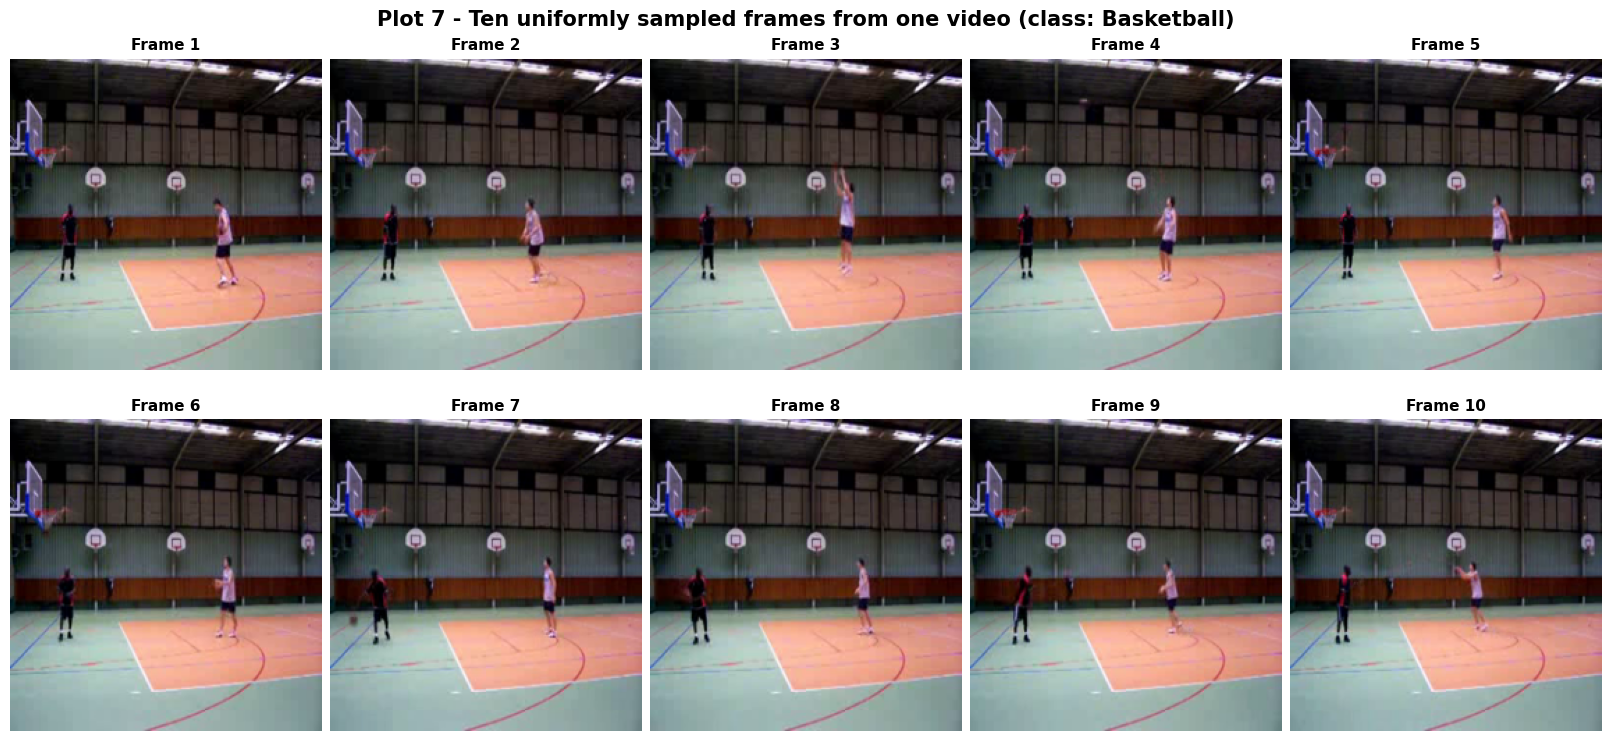

[saved] /content/plots/plot7_video_sample_frames.png


In [ ]:
assert all_video_frames.shape[0] > 0, "Video array is empty - re-run Cell 13."
v = 0
fig, axes = plt.subplots(2, 5, figsize=(16, 7.5))
for t, ax in enumerate(axes.ravel()):
    ax.imshow(all_video_frames[v, t])         
    ax.set_title(f"Frame {t + 1}", fontsize=11)
    ax.axis('off')
fig.suptitle(f"Plot 7 - Ten uniformly sampled frames from one video (class: {video_labels[v]})")
save_show(fig, "plot7_video_sample_frames")

In [ ]:
base_cnn = keras.applications.MobileNetV2(weights='imagenet', include_top=False,
                                          input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_cnn.trainable = False                    
fe_in  = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
fe_out = layers.GlobalAveragePooling2D()(base_cnn(fe_in, training=False))
feature_extractor = keras.Model(fe_in, fe_out, name="MobileNetV2_feature_extractor")

n_vid = all_video_frames.shape[0]
flat  = keras.applications.mobilenet_v2.preprocess_input(
            all_video_frames.reshape(-1, IMG_SIZE, IMG_SIZE, 3).astype('float32'))
feats = feature_extractor.predict(flat, batch_size=64, verbose=1)
del flat

D = int(feats.shape[-1])
X_video = feats.reshape(n_vid, NUM_FRAMES, D).astype('float32')

report("CNN FEATURE EXTRACTION (manual section 20)", pd.DataFrame({
    'Quantity': ['Pretrained CNN', 'CNN trainable', 'Frame input shape',
                 'CNN feature dimension D', 'Tensor supplied to the recurrent network (one video)',
                 'Tensor supplied to the recurrent network (batch of B)',
                 'Full feature tensor'],
    'Value'   : ['MobileNetV2 (ImageNet)', 'No (frozen)', f"{IMG_SIZE} x {IMG_SIZE} x 3",
                 f"{D}", f"({NUM_FRAMES}, {D})", f"(B, {NUM_FRAMES}, {D})", f"{X_video.shape}"]}))

Xv_tr, Xv_tmp, yv_tr, yv_tmp = train_test_split(X_video, y_video, test_size=0.30,
                                                random_state=SEED, stratify=y_video)
Xv_val, Xv_te, yv_val, yv_te = train_test_split(Xv_tmp, yv_tmp, test_size=0.50,
                                                random_state=SEED, stratify=yv_tmp)
print(f"Video train / validation / test : {Xv_tr.shape} / {Xv_val.shape} / {Xv_te.shape}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 44s 3s/step

CNN FEATURE EXTRACTION (manual section 20)
                                             Quantity                  Value
                                       Pretrained CNN MobileNetV2 (ImageNet)
                                        CNN trainable            No (frozen)
                                    Frame input shape          224 x 224 x 3
                              CNN feature dimension D                   1280
 Tensor supplied to the recurrent network (one video)             (10, 1280)
Tensor supplied to the recurrent network (batch of B)          (B, 10, 1280)
                                  Full feature tensor        (100, 10, 1280)

Video train / validation / test : (70, 10, 1280) / (15, 10, 1280) / (15, 10, 1280)



==========================  CNN-LSTM  ==========================
Epoch 1/30
3/3 - 3s - 967ms/step - accuracy: 0.3286 - loss: 1.3873 - val_accuracy: 0.6667 - val_loss: 1.0982
Epoch 2/30
3/3 - 0s - 73ms/step - accuracy: 0.7286 - loss: 0.9192 - val_accuracy: 0.7333 - val_loss: 0.8457
Epoch 3/30
3/3 - 0s - 62ms/step - accuracy: 0.7571 - loss: 0.6561 - val_accuracy: 0.7333 - val_loss: 0.7987
Epoch 4/30
3/3 - 0s - 46ms/step - accuracy: 0.8000 - loss: 0.4971 - val_accuracy: 0.7333 - val_loss: 0.5739
Epoch 5/30
3/3 - 0s - 44ms/step - accuracy: 0.9571 - loss: 0.3493 - val_accuracy: 0.7333 - val_loss: 0.5991
Epoch 6/30
3/3 - 0s - 44ms/step - accuracy: 0.9571 - loss: 0.2674 - val_accuracy: 0.8000 - val_loss: 0.6086
Epoch 7/30
3/3 - 0s - 43ms/step - accuracy: 0.9714 - loss: 0.1767 - val_accuracy: 0.7333 - val_loss: 0.5539
Epoch 8/30
3/3 - 0s - 43ms/step - accuracy: 0.9857 - loss: 0.1366 - val_accuracy: 0.8667 - val_loss: 0.5365
Epoch 9/30
3/3 - 0s - 43ms/step - accuracy: 1.0000 - loss: 0.0953 - v

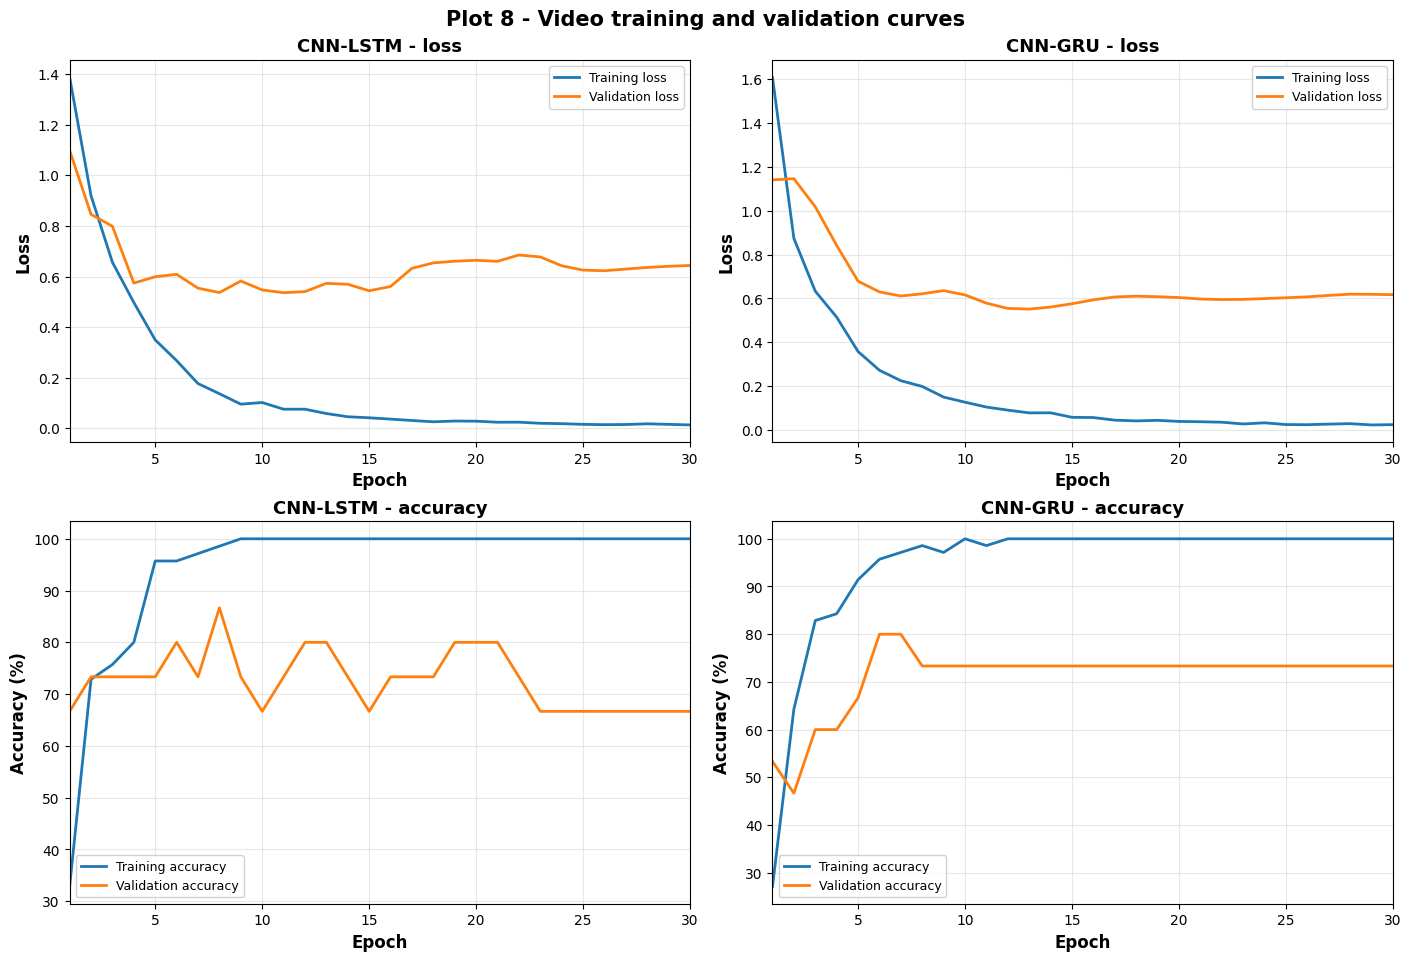

[saved] /content/plots/plot8_video_curves.png

--- Sample predictions: CNN-LSTM (confidence from the trained model) ---

VIDEO PREDICTIONS - CNN-LSTM (manual section 19)
Predicted class : Basketball
Actual class    : Basketball
Confidence      : 0.56

Predicted class : Biking
Actual class    : Biking
Confidence      : 0.99

Predicted class : WalkingWithDog
Actual class    : WalkingWithDog
Confidence      : 1.00

Predicted class : Basketball
Actual class    : Basketball
Confidence      : 0.98

Predicted class : TennisSwing
Actual class    : TennisSwing
Confidence      : 0.99



--- Sample predictions: CNN-GRU (confidence from the trained model) ---

VIDEO PREDICTIONS - CNN-GRU (manual section 19)
Predicted class : Basketball
Actual class    : Basketball
Confidence      : 0.66

Predicted class : Biking
Actual class    : Biking
Confidence      : 0.98

Predicted class : WalkingWithDog
Actual class    : WalkingWithDog
Confidence      : 0.99

Predicted class : Basketball
Actual class    : Ba

In [ ]:
def build_video_model(kind, D, n_classes, units=RNN_UNITS):
    keras.utils.set_random_seed(SEED)
    inp = keras.Input(shape=(NUM_FRAMES, D))
    x   = RECURRENT[kind](units)(inp)
    x   = layers.Dropout(DROPOUT)(x)
    out = layers.Dense(n_classes, activation='softmax')(x)
    m = keras.Model(inp, out, name=f"CNN_{kind}")
    m.compile(optimizer=keras.optimizers.Adam(learning_rate=LR),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
    return m

video_res = {}
for kind in ['LSTM', 'GRU']:
    print(f"\n{'=' * 26}  CNN-{kind}  {'=' * 26}")
    m = build_video_model(kind, D, N_VCLASS)
    t0 = time.time()
    h = m.fit(Xv_tr, yv_tr, validation_data=(Xv_val, yv_val),
              epochs=EPOCHS, batch_size=BATCH_SIZE, verbose=2)
    r = evaluate_model(m, Xv_te, yv_te)
    r.update(model=m, history=h.history, params=trainable_params(m), time=time.time() - t0)
    video_res[kind] = r
    print(f"\nCNN-{kind}: accuracy = {r['accuracy']:.2f}% | macro F1 = {r['f1']:.2f}% | "
          f"parameters = {r['params']} | time = {r['time']:.1f} s")

fig, axes = plt.subplots(2, 2, figsize=(14, 9.5))
for col, kind in enumerate(['LSTM', 'GRU']):
    h  = video_res[kind]['history']
    ep = np.arange(1, len(h['loss']) + 1)
    axes[0, col].plot(ep, h['loss'],     label='Training loss')
    axes[0, col].plot(ep, h['val_loss'], label='Validation loss')
    axes[0, col].set_ylabel("Loss"); axes[0, col].set_title(f"CNN-{kind} - loss")
    axes[1, col].plot(ep, np.array(h['accuracy']) * 100,     label='Training accuracy')
    axes[1, col].plot(ep, np.array(h['val_accuracy']) * 100, label='Validation accuracy')
    axes[1, col].set_ylabel("Accuracy (%)"); axes[1, col].set_title(f"CNN-{kind} - accuracy")
    for r_ in range(2):
        axes[r_, col].set_xlabel("Epoch"); axes[r_, col].set_xlim(1, len(ep))
        axes[r_, col].grid(alpha=0.3); axes[r_, col].legend()
fig.suptitle("Plot 8 - Video training and validation curves")
save_show(fig, "plot8_video_curves")

for kind in ['LSTM', 'GRU']:
    prob = video_res[kind]['y_prob']
    print(f"\n--- Sample predictions: CNN-{kind} (confidence from the trained model) ---")
    lines = []
    for i in range(min(5, len(yv_te))):
        p = int(prob[i].argmax())
        lines.append(f"Predicted class : {VIDEO_CLASSES[p]}\n"
                     f"Actual class    : {VIDEO_CLASSES[int(yv_te[i])]}\n"
                     f"Confidence      : {prob[i][p]:.2f}\n")
    report(f"VIDEO PREDICTIONS - CNN-{kind} (manual section 19)", "\n".join(lines))

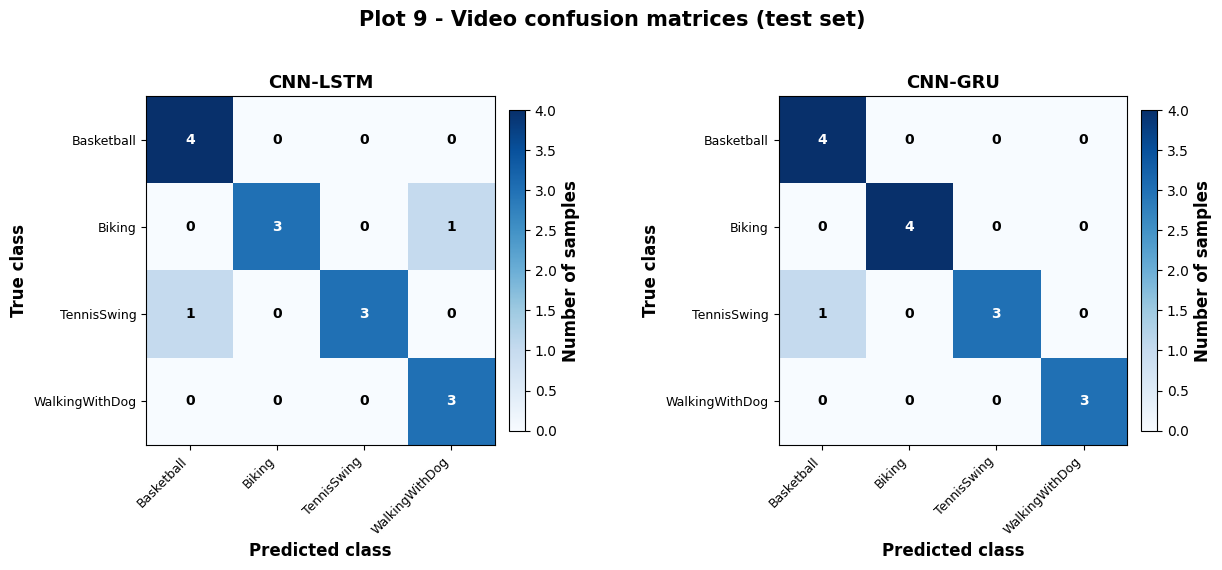

[saved] /content/plots/plot9_video_confusion_matrices.png

VIDEO PER-CLASS RECOGNITION RATE (%)
  Action class  CNN-LSTM  CNN-GRU
    Basketball     100.0    100.0
        Biking      75.0    100.0
   TennisSwing      75.0     75.0
WalkingWithDog     100.0    100.0



In [ ]:
vcms = {f"CNN-{k}": confusion_matrix(yv_te, video_res[k]['y_pred'], labels=range(N_VCLASS))
        for k in ['LSTM', 'GRU']}
plot_confusion_group(vcms, VIDEO_CLASSES, "Plot 9 - Video confusion matrices (test set)",
                     "plot9_video_confusion_matrices")

report("VIDEO PER-CLASS RECOGNITION RATE (%)",
       pd.DataFrame({name: (cm.diagonal() / np.maximum(cm.sum(axis=1), 1) * 100).round(1)
                     for name, cm in vcms.items()}, index=VIDEO_CLASSES)
         .reset_index().rename(columns={'index': 'Action class'}))

In [ ]:
S2S_N, S2S_LEN = 10000, 6           
START          = 10                  
S2S_VOCAB      = 11
S2S_UNITS      = 64
S2S_EPOCHS     = 25

def make_reversal(n=S2S_N, L=S2S_LEN, seed=SEED):
    rng = np.random.RandomState(seed)
    X = rng.randint(1, 10, size=(n, L))         
    return X, X[:, ::-1].copy()                 

def decoder_input(Y):
    """Teacher forcing: <start> then the target shifted right by one."""
    return np.concatenate([np.full((len(Y), 1), START), Y[:, :-1]], axis=1)

def build_seq2seq(vocab=S2S_VOCAB, emb=32, units=S2S_UNITS):
    keras.utils.set_random_seed(SEED)
    enc_in  = keras.Input(shape=(None,), dtype='int32', name='encoder_input')
    enc_emb = layers.Embedding(vocab, emb, name='encoder_embedding')(enc_in)
    _, h, c = layers.LSTM(units, return_state=True, name='encoder_lstm')(enc_emb)

    dec_in    = keras.Input(shape=(None,), dtype='int32', name='decoder_input')
    dec_emb   = layers.Embedding(vocab, emb, name='decoder_embedding')
    dec_lstm  = layers.LSTM(units, return_sequences=True, return_state=True, name='decoder_lstm')
    dec_dense = layers.Dense(vocab, activation='softmax', name='decoder_output')
    x, _, _   = dec_lstm(dec_emb(dec_in), initial_state=[h, c])
    train_m   = keras.Model([enc_in, dec_in], dec_dense(x), name='seq2seq')
    train_m.compile(optimizer=keras.optimizers.Adam(1e-3),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    enc_m = keras.Model(enc_in, [h, c], name='encoder_inference')
    tok   = keras.Input(shape=(1,), dtype='int32')
    s_h   = keras.Input(shape=(units,))
    s_c   = keras.Input(shape=(units,))
    y1, h1, c1 = dec_lstm(dec_emb(tok), initial_state=[s_h, s_c])
    dec_m = keras.Model([tok, s_h, s_c], [dec_dense(y1), h1, c1], name='decoder_inference')
    return train_m, enc_m, dec_m

def greedy_decode(enc_m, dec_m, X, out_len):
    h, c = enc_m.predict(X, batch_size=512, verbose=0)      
    tok, out = np.full((len(X), 1), START, dtype='int32'), []
    for _ in range(out_len):                               
        p, h, c = dec_m.predict([tok, h, c], batch_size=512, verbose=0)
        nxt = p[:, -1, :].argmax(-1).astype('int32')
        out.append(nxt); tok = nxt[:, None]
    return np.stack(out, axis=1)

def s2s_metrics(enc_m, dec_m, Xt, Yt):
    pred = greedy_decode(enc_m, dec_m, Xt, Yt.shape[1])
    return (pred == Yt).mean() * 100, (pred == Yt).all(axis=1).mean() * 100, pred

Xs, Ys = make_reversal()
Xs_tr, Xs_tmp, Ys_tr, Ys_tmp = train_test_split(Xs, Ys, test_size=0.30, random_state=SEED)
Xs_val, Xs_te, Ys_val, Ys_te = train_test_split(Xs_tmp, Ys_tmp, test_size=0.50, random_state=SEED)
print(f"Seq2Seq train / validation / test : {Xs_tr.shape} / {Xs_val.shape} / {Xs_te.shape}")

s2s, s2s_enc, s2s_dec = build_seq2seq()
s2s.summary()
h_s2s = s2s.fit([Xs_tr, decoder_input(Ys_tr)], Ys_tr,
                validation_data=([Xs_val, decoder_input(Ys_val)], Ys_val),
                epochs=S2S_EPOCHS, batch_size=128, verbose=2)

tok_acc, seq_acc, pred = s2s_metrics(s2s_enc, s2s_dec, Xs_te, Ys_te)

report("SEQUENCE-TO-SEQUENCE EVALUATION (manual section 24)", pd.DataFrame({
    'Measure': ['Token accuracy (%)', 'Sequence accuracy (%)',
                'Training loss', 'Validation loss', 'Trainable parameters'],
    'Value'  : [f"{tok_acc:.2f}", f"{seq_acc:.2f}",
                f"{h_s2s.history['loss'][-1]:.4f}", f"{h_s2s.history['val_loss'][-1]:.4f}",
                f"{trainable_params(s2s)}"]}))

report("SEQUENCE-TO-SEQUENCE TEST EXAMPLES (manual section 23)", pd.DataFrame({
    'Sample'          : range(1, 6),
    'Input Sequence'  : [Xs_te[i].tolist() for i in range(5)],
    'Expected Output' : [Ys_te[i].tolist() for i in range(5)],
    'Predicted Output': [pred[i].tolist()  for i in range(5)],
    'Exact Match'     : [bool((pred[i] == Ys_te[i]).all()) for i in range(5)]}))

Seq2Seq train / validation / test : (7000, 6) / (1500, 6) / (1500, 6)


Model: "seq2seq"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ encoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_input       │ (None, None)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_embedding   │ (None, None, 32)  │        352 │ encoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_embedding   │ (None, 1, 32)     │        352 │ decoder_input[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ encoder_lstm (LSTM) │ [(None, 64),      │     24,832 │ encoder_embeddin… │
│                     │ (None, 64),       │            │                   │
│                     │ (None, 64)]       │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_lstm (LSTM) │ [(None, 1, 64),   │     24,832 │ decoder_embeddin… │
│                     │ (None, 64),       │            │ encoder_lstm[0][… │
│                     │ (None, 64)]       │            │ encoder_lstm[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ decoder_output      │ (None, 1, 11)     │        715 │ decoder_lstm[0][… │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 51,083 (199.54 KB)

 Trainable params: 51,083 (199.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/25
55/55 - 6s - 113ms/step - accuracy: 0.2067 - loss: 2.1711 - val_accuracy: 0.3152 - val_loss: 1.8629
Epoch 2/25
55/55 - 1s - 21ms/step - accuracy: 0.3867 - loss: 1.6021 - val_accuracy: 0.5078 - val_loss: 1.2639
Epoch 3/25
55/55 - 1s - 21ms/step - accuracy: 0.7147 - loss: 0.8810 - val_accuracy: 0.8776 - val_loss: 0.5647
Epoch 4/25
55/55 - 1s - 22ms/step - accuracy: 0.9266 - loss: 0.4093 - val_accuracy: 0.9597 - val_loss: 0.2966
Epoch 5/25
55/55 - 1s - 23ms/step - accuracy: 0.9732 - loss: 0.2346 - val_accuracy: 0.9827 - val_loss: 0.1914
Epoch 6/25
55/55 - 1s - 21ms/step - accuracy: 0.9878 - loss: 0.1559 - val_accuracy: 0.9934 - val_loss: 0.1302
Epoch 7/25
55/55 - 1s - 21ms/step - accuracy: 0.9935 - loss: 0.1124 - val_accuracy: 0.9951 - val_loss: 0.1009
Epoch 8/25
55/55 - 1s - 21ms/step - accuracy: 0.9958 - loss: 0.0867 - val_accuracy: 0.9941 - val_loss: 0.0884
Epoch 9/25
55/55 - 1s - 23ms/step - accuracy: 0.9973 - loss: 0.0692 - val_accuracy: 0.9971 - val_loss: 0.0632
Epoch 10/

In [ ]:
rows = []
for k in MODELS:
    r = results[k]
    rows.append([k, f"{r['accuracy']:.2f}", f"{r['precision']:.2f}",
                 f"{r['recall']:.2f}", f"{r['f1']:.2f}", r['params']])
for k in ['LSTM', 'GRU']:
    r = video_res[k]
    rows.append([f"CNN-{k}", f"{r['accuracy']:.2f}", f"{r['precision']:.2f}",
                 f"{r['recall']:.2f}", f"{r['f1']:.2f}", r['params']])
report("CONSOLIDATED RESULTS (manual section 25)",
       pd.DataFrame(rows, columns=['Model', 'Accuracy (%)', 'Precision (%)',
                                   'Recall (%)', 'F1 (%)', 'Parameters']))

report("CONSOLIDATED RESULTS - SEQUENCE-TO-SEQUENCE TASK (manual section 25)",
       pd.DataFrame({'Task': [f'Sequence reversal ({S2S_LEN} -> {S2S_LEN})'],
                     'Token Accuracy (%)'   : [f"{tok_acc:.2f}"],
                     'Sequence Accuracy (%)': [f"{seq_acc:.2f}"],
                     'Training Loss'        : [f"{h_s2s.history['loss'][-1]:.4f}"],
                     'Validation Loss'      : [f"{h_s2s.history['val_loss'][-1]:.4f}"],
                     'Parameters'           : [trainable_params(s2s)]}))


CONSOLIDATED RESULTS (manual section 25)
   Model Accuracy (%) Precision (%) Recall (%) F1 (%)  Parameters
     RNN        81.11         82.37      79.87  80.23        1974
    LSTM        96.22         96.33      96.36  96.29        6006
     GRU        96.22         96.36      96.21  96.28        4758
CNN-LSTM        86.67         88.75      87.50  86.51      168196
 CNN-GRU        93.33         95.00      93.75  93.65      126276


CONSOLIDATED RESULTS - SEQUENCE-TO-SEQUENCE TASK (manual section 25)
                      Task Token Accuracy (%) Sequence Accuracy (%) Training Loss Validation Loss  Parameters
Sequence reversal (6 -> 6)             100.00                100.00        0.0080          0.0104       51083



Ex1 | units = 16 | RNN  | F1 = 74.04%
Ex1 | units = 16 | LSTM | F1 = 95.11%
Ex1 | units = 16 | GRU  | F1 = 96.72%
Ex1 | units = 32 | RNN  | F1 = 80.23%
Ex1 | units = 32 | LSTM | F1 = 96.29%
Ex1 | units = 32 | GRU  | F1 = 96.28%
Ex1 | units = 64 | RNN  | F1 = 68.26%
Ex1 | units = 64 | LSTM | F1 = 96.51%
Ex1 | units = 64 | GRU  | F1 = 96.50%

EXERCISE 1 - Effect of the number of recurrent units
Model  Units Accuracy (%) Macro F1 (%)  Parameters Training Time (s)
  RNN     16        74.89        74.04         790              47.8
  RNN     32        81.11        80.23        1974              46.9
  RNN     64        70.89        68.26        5878              54.4
 LSTM     16        95.11        95.11        2038              87.4
 LSTM     32        96.22        96.29        6006              95.7
 LSTM     64        96.44        96.51       20086             127.8
  GRU     16        96.67        96.72        1670             131.4
  GRU     32        96.22        96.28        4758  

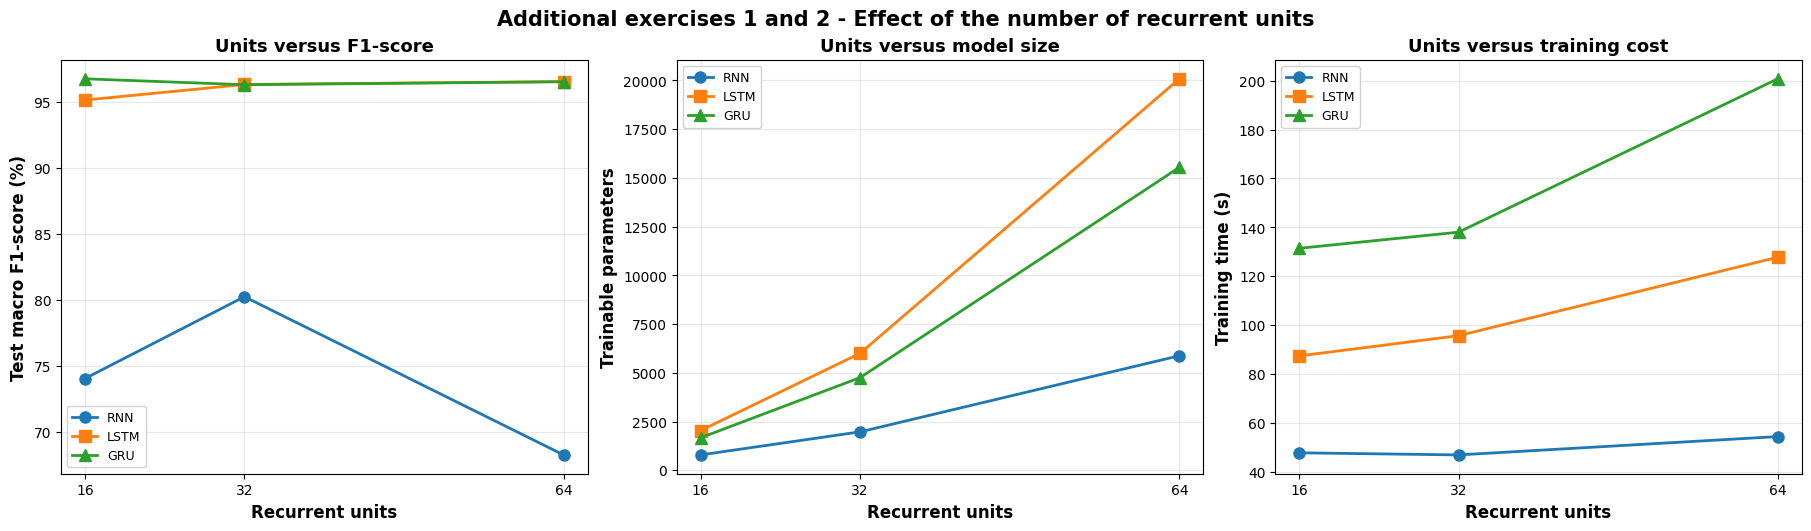

[saved] /content/plots/exercise1_2_recurrent_units.png
Ex3 | RNN with 2 layers | F1 = 77.98%
Ex3 | LSTM with 2 layers | F1 = 95.83%
Ex3 | GRU with 2 layers | F1 = 96.51%

EXERCISE 3 - One versus two recurrent layers
  Configuration Accuracy (%) Macro F1 (%)  Parameters Training Time (s)
  RNN - 1 layer        81.11        80.23        1974              46.9
 RNN - 2 layers        78.67        77.98        4054             104.3
 LSTM - 1 layer        96.22        96.29        6006              95.7
LSTM - 2 layers        95.78        95.83       14326             250.3
  GRU - 1 layer        96.22        96.28        4758             138.0
 GRU - 2 layers        96.44        96.51       11094             274.6


EXERCISE 4 - Unidirectional versus bidirectional LSTM
        Configuration Accuracy (%) Macro F1 (%)  Parameters Training Time (s)
LSTM - unidirectional        96.22        96.29        6006              95.7
 LSTM - bidirectional        95.78        95.85       11894         

In [ ]:
COLS = ['Configuration', 'Accuracy (%)', 'Macro F1 (%)', 'Parameters', 'Training Time (s)']
def row(name, r):
    return [name, f"{r['accuracy']:.2f}", f"{r['f1']:.2f}", r['params'], f"{r['time']:.1f}"]

units_res = {u: {} for u in [16, 32, 64]}
for u in [16, 32, 64]:
    for k in MODELS:
        units_res[u][k] = results[k] if u == RNN_UNITS else \
            run_experiment(k, X_tr, y_tr, X_val, y_val, X_te, y_te, units=u)
        print(f"Ex1 | units = {u:2d} | {k:4s} | F1 = {units_res[u][k]['f1']:.2f}%")
report("EXERCISE 1 - Effect of the number of recurrent units",
       pd.DataFrame([[k, u, f"{units_res[u][k]['accuracy']:.2f}", f"{units_res[u][k]['f1']:.2f}",
                      units_res[u][k]['params'], f"{units_res[u][k]['time']:.1f}"]
                     for k in MODELS for u in [16, 32, 64]],
                    columns=['Model', 'Units', 'Accuracy (%)', 'Macro F1 (%)',
                             'Parameters', 'Training Time (s)']))

report("EXERCISE 2 - GRU versus LSTM with the same number of recurrent units",
       pd.DataFrame([[u, k, f"{units_res[u][k]['accuracy']:.2f}", f"{units_res[u][k]['f1']:.2f}",
                      units_res[u][k]['params'], f"{units_res[u][k]['time']:.1f}"]
                     for u in [16, 32, 64] for k in ['LSTM', 'GRU']],
                    columns=['Units', 'Model', 'Accuracy (%)', 'Macro F1 (%)',
                             'Parameters', 'Training Time (s)']))

fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
for k, mk in zip(MODELS, ['o', 's', '^']):
    us = [16, 32, 64]
    axes[0].plot(us, [units_res[u][k]['f1']     for u in us], marker=mk, markersize=8, label=k)
    axes[1].plot(us, [units_res[u][k]['params'] for u in us], marker=mk, markersize=8, label=k)
    axes[2].plot(us, [units_res[u][k]['time']   for u in us], marker=mk, markersize=8, label=k)
axes[0].set_ylabel("Test macro F1-score (%)"); axes[0].set_title("Units versus F1-score")
axes[1].set_ylabel("Trainable parameters");    axes[1].set_title("Units versus model size")
axes[2].set_ylabel("Training time (s)");       axes[2].set_title("Units versus training cost")
for a in axes:
    a.set_xlabel("Recurrent units"); a.set_xticks([16, 32, 64]); a.grid(alpha=0.3); a.legend()
fig.suptitle("Additional exercises 1 and 2 - Effect of the number of recurrent units")
save_show(fig, "exercise1_2_recurrent_units")

ex3 = []
for k in MODELS:
    r2 = run_experiment(k, X_tr, y_tr, X_val, y_val, X_te, y_te, n_layers=2)
    ex3 += [row(f"{k} - 1 layer", results[k]), row(f"{k} - 2 layers", r2)]
    print(f"Ex3 | {k} with 2 layers | F1 = {r2['f1']:.2f}%")
report("EXERCISE 3 - One versus two recurrent layers", pd.DataFrame(ex3, columns=COLS))

r_bi = run_experiment('LSTM', X_tr, y_tr, X_val, y_val, X_te, y_te, bidirectional=True)
report("EXERCISE 4 - Unidirectional versus bidirectional LSTM",
       pd.DataFrame([row("LSTM - unidirectional", results['LSTM']),
                     row("LSTM - bidirectional",  r_bi)], columns=COLS))

report("EXERCISE 5 - Sequence length versus computational cost",
       pd.DataFrame({'Sequence Length': SEQ_LENGTHS,
                     **{f"{k} Total (s)": [f"{seq_res[T][k]['time']:.1f}" for T in SEQ_LENGTHS]
                        for k in MODELS},
                     **{f"{k} Per Epoch (s)": [f"{seq_res[T][k]['time'] / EPOCHS:.2f}"
                                               for T in SEQ_LENGTHS] for k in MODELS}}))

report("EXERCISE 6 - CNN-LSTM versus CNN-GRU on identical MobileNetV2 features",
       pd.DataFrame([row("CNN-LSTM", video_res['LSTM']),
                     row("CNN-GRU",  video_res['GRU'])], columns=COLS))

OUT_LEN = 3                                  
Ys_tr3, Ys_val3, Ys_te3 = Ys_tr[:, :OUT_LEN], Ys_val[:, :OUT_LEN], Ys_te[:, :OUT_LEN]
s2s3, s2s3_enc, s2s3_dec = build_seq2seq()
h3 = s2s3.fit([Xs_tr, decoder_input(Ys_tr3)], Ys_tr3,
              validation_data=([Xs_val, decoder_input(Ys_val3)], Ys_val3),
              epochs=S2S_EPOCHS, batch_size=128, verbose=0)
tok3, seq3, pred3 = s2s_metrics(s2s3_enc, s2s3_dec, Xs_te, Ys_te3)
train_loss_3, val_loss_3 = h3.history['loss'][-1], h3.history['val_loss'][-1]

report(f"EXERCISE 7 - Seq2Seq with output length {OUT_LEN} different from input length {S2S_LEN}",
       pd.DataFrame({
           'Task'                 : [f'Full reversal ({S2S_LEN} -> {S2S_LEN})',
                                     f'Last {OUT_LEN} reversed ({S2S_LEN} -> {OUT_LEN})'],
           'Token Accuracy (%)'   : [f"{tok_acc:.2f}", f"{tok3:.2f}"],
           'Sequence Accuracy (%)': [f"{seq_acc:.2f}", f"{seq3:.2f}"],
           'Training Loss'        : [f"{h_s2s.history['loss'][-1]:.4f}", f"{train_loss_3:.4f}"],
           'Validation Loss'      : [f"{h_s2s.history['val_loss'][-1]:.4f}", f"{val_loss_3:.4f}"]}))

report(f"EXERCISE 7 - Examples ({S2S_LEN} -> {OUT_LEN})", pd.DataFrame({
    'Sample'          : range(1, 6),
    'Input Sequence'  : [Xs_te[i].tolist()  for i in range(5)],
    'Expected Output' : [Ys_te3[i].tolist() for i in range(5)],
    'Predicted Output': [pred3[i].tolist()  for i in range(5)]}))

In [ ]:
RESULTS_TXT = "/content/results.txt"
with open(RESULTS_TXT, "w") as f:
    f.write("CS3807 - Deep Learning Laboratory - Experiment 6\n")
    f.write("RNN, LSTM and GRU for Sequence Learning and Video Understanding\n")
    f.write(f"Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write("\n".join(REPORT))

plots = sorted(os.listdir(PLOT_DIR))
print(f"Tables written to {RESULTS_TXT} ({len(REPORT)} tables)")
print(f"\nFigures saved at 600 dpi in {PLOT_DIR}:")
for p in plots:
    print("   ", p)

get_ipython().system(f'cd /content && zip -qr experiment6_outputs.zip plots results.txt')
print("\nDownload /content/experiment6_outputs.zip from the Files panel "
      "(folder icon on the left) for every plot and table.")

Tables written to /content/results.txt (29 tables)

Figures saved at 600 dpi in /content/plots:
    exercise1_2_recurrent_units.png
    plot1_sensor_signal_vs_time.png
    plot2_loss_curves.png
    plot3_accuracy_curves.png
    plot4_confusion_matrices.png
    plot5_model_comparison.png
    plot6_sequence_length_vs_f1.png
    plot7_video_sample_frames.png
    plot8_video_curves.png
    plot9_video_confusion_matrices.png

Download /content/experiment6_outputs.zip from the Files panel (folder icon on the left) for every plot and table.
